# 02. Missing Values & Duplicates
## 📚 Learning Objectives

By completing this notebook, you will:
- Identify and handle missing values
- Find and remove duplicates
- Apply imputation and document choices

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 02 "Data Cleaning" — the same decisions (drop or impute?), now documented as choices with consequences.

**Used later in:** Course 05 — Unit 4, lesson 02, which repeats them as a required step before model training, and Course 12 (AIAT 126) — Unit 3.

---


## 🎯 The case: England, August 2020 — filling in 700,000 missing exam results

COVID-19 cancelled the 2020 A-level exams, so **Ofqual**, the English exam regulator, had a
missing-value problem of national scale: every grade for every candidate. Its answer was
imputation. Teachers submitted predicted grades; an algorithm then "standardised" them
using each school's historical results distribution and the cohort's prior attainment.

The results were published on 13 August 2020. Roughly **36%** of grades came out **one
grade below** the teacher's assessment and about **3%** two grades below. The correction was
not spread evenly: because the model leaned on a school's past performance and treated
small cohorts differently from large ones, students in large state-school classes were
downgraded while small independent-school classes were largely protected. University
offers collapsed for students who had never sat the exam. After four days of protest the
government withdrew the algorithm entirely on **17 August 2020** and reverted to teacher
assessments.

Every ingredient of this lesson is in that story: values were missing; the fill was
computed from other columns; the fill *looked* statistically defensible; and the choice of
fill changed real outcomes for real people, unevenly.

**What goes wrong without this lesson.** You will measure the same effect in miniature
below. Filling 177 missing Titanic ages with the mean leaves the mean untouched — by
construction — but drops the standard deviation from **14.53 to 13.00**. You did not
recover 177 ages. You invented 177 perfectly average passengers, and every confidence
interval downstream is now too narrow. Imputation always understates variance; the only
question is whether you know it.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Solving the Problem from Example 1

**Remember the dead end from Example 1?**
- We successfully loaded data from multiple sources
- But the loaded data had quality issues - missing values and duplicates
- We couldn't proceed with analysis until we cleaned the data

**This notebook solves that problem!**
- We'll learn how to **detect** missing values and duplicates
- We'll learn **strategies** for handling them (fill, drop, impute)
- We'll **clean the data** so we can proceed with analysis

**This solves the data quality problem from Example 1!**

---

## The Story: Fixing Your Data

Imagine you have a shopping list. **Before** shopping, you check for missing items (add them) 
and duplicates (remove them). **After** fixing the list, you can shop efficiently!

Same with data: **Before** analyzing, we fix missing values (impute or remove) and duplicates 
(remove). **After** cleaning, we have reliable data for analysis!

---

## Why Missing Values & Duplicates Matter

These issues cause major problems:
- **Missing Values**: Break ML algorithms (can't train on NaN)
- **Duplicates**: Bias your results (same data counted multiple times)
- **Data Quality**: Dirty data = unreliable insights
- **Model Performance**: Clean data = better models

## Learning Objectives
1. Identify missing values and understand their patterns
2. Handle missing values (remove or impute)
3. Detect and remove duplicates
4. Visualize missing data patterns
5. Make informed decisions about cleaning strategies


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- DataFrame with missing values and duplicates
- pandas

**Outputs:** What you'll see when you run the cells

- Cleaned DataFrame
- Counts, imputation results, printed summaries

---

In [1]:
# WHAT: Import the cleaning toolkit; missingno is optional and guarded by try/except.
# WHY: The guard keeps the notebook runnable everywhere - an optional visual tool should never block the core lesson.

# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import missingno (optional - for advanced missing data visualization)
try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False
    msno = None  # Set to None if not available

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Data manipulation and analysis (DataFrames)")
print("   - numpy: Numerical operations and NaN handling")
print("   - matplotlib: Create visualizations")
print("   - seaborn: Statistical visualizations (heatmaps)")
if MISSINGNO_AVAILABLE:
    print("   - missingno: Visualize missing data patterns (specialized tool)")
else:
    print("   - missingno: Not available (optional library)")

print("\n" + "=" * 70)
print("Example 2: Missing Values & Duplicates")
print("=" * 70)
print("\n📚 Prerequisites: Example 1 completed, data loading knowledge")
print("🔗 This is the SECOND example in Unit 2 - cleaning loaded data")
print("🎯 Goal: Master detecting and handling missing values and duplicates\n")


✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Data manipulation and analysis (DataFrames)
   - numpy: Numerical operations and NaN handling
   - matplotlib: Create visualizations
   - seaborn: Statistical visualizations (heatmaps)
   - missingno: Not available (optional library)

Example 2: Missing Values & Duplicates

📚 Prerequisites: Example 1 completed, data loading knowledge
🔗 This is the SECOND example in Unit 2 - cleaning loaded data
🎯 Goal: Master detecting and handling missing values and duplicates



## Part 1: Meeting Real Data With Real Problems

**BEFORE**: We need to practice cleaning, and we need data that genuinely has problems.

**AFTER**: We'll load two real, published datasets that already contain both defects!

**Why this matters**: Nobody plants these gaps for you. The Titanic manifest is missing
177 ages because those ages were never written down, and the Montgomery County 911 log
contains rows the dispatch system genuinely recorded twice.


## Step 1: Loading Data That Already Has Issues

**BEFORE**: We could invent a broken table - but then we would only ever meet the
problems we chose to invent.

**AFTER**: We load real files and *discover* what is wrong with them.


In [2]:
# WHAT: Load two real datasets - the Titanic manifest (missing values) and the 911 call log (duplicate rows).
# WHY: Practising on genuine defects teaches you to look; practising on planted ones only teaches you to find what you hid.

print("\n1. Loading Real Data With Real Issues")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'

# Dataset A: the Titanic passenger manifest. Small enough to inspect row by row,
# and its missing values are the classic teaching case.
df = pd.read_csv(DATA_DIR + 'titanic.csv')
print(f"✓ Titanic manifest: {len(df)} rows x {df.shape[1]} columns")
print(f"  Columns with gaps: "
      f"{', '.join(df.columns[df.isnull().any()])}")

# Dataset B: Montgomery County 911 dispatch log. We need it later because Titanic
# has NO exact duplicate rows - and a lesson about duplicates needs real duplicates.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv')
print(f"✓ Montgomery County 911 log: {len(calls):,} rows x {calls.shape[1]} columns")
print(f"  Columns with gaps: {', '.join(calls.columns[calls.isnull().any()])}")

print("\nNothing below was planted. Every defect you are about to fix was already")
print("in these published files.")



1. Loading Real Data With Real Issues
----------------------------------------------------------------------
✓ Titanic manifest: 891 rows x 12 columns
  Columns with gaps: Age, Cabin, Embarked


✓ Montgomery County 911 log: 663,522 rows x 9 columns
  Columns with gaps: zip, twp

Nothing below was planted. Every defect you are about to fix was already
in these published files.


## Part 2: Detecting Missing Values

**BEFORE**: You have data but don't know what's missing.

**AFTER**: You'll identify all missing values and see their patterns!

**Why this matters**: You can't fix what you can't see - detection is the first step!

## Step 2: Detecting Missing Values

**BEFORE**: Data has missing values but we can't see them clearly.

**AFTER**: We'll count, visualize, and understand real missing value patterns!

Watch the heatmap in particular: the gaps in `Cabin` are not scattered at random —
they cluster by ticket class, which is a clue about *why* they are missing.




2. Detecting Missing Values
----------------------------------------------------------------------

Missing values per column
  Column  Missing Count  Missing %
   Cabin            687  77.104377
     Age            177  19.865320
Embarked              2   0.224467

Total missing values: 866



✓ Missing values visualization saved

Share of passengers with NO cabin recorded, by ticket class:
   Class 1: 18.5%
   Class 2: 91.3%
   Class 3: 97.6%
   The gaps are NOT random. Cheaper tickets rarely came with a recorded cabin,
   so 'Cabin is missing' is itself information about the passenger.
   Statisticians call this MNAR - missing not at random (Rubin, 1976).


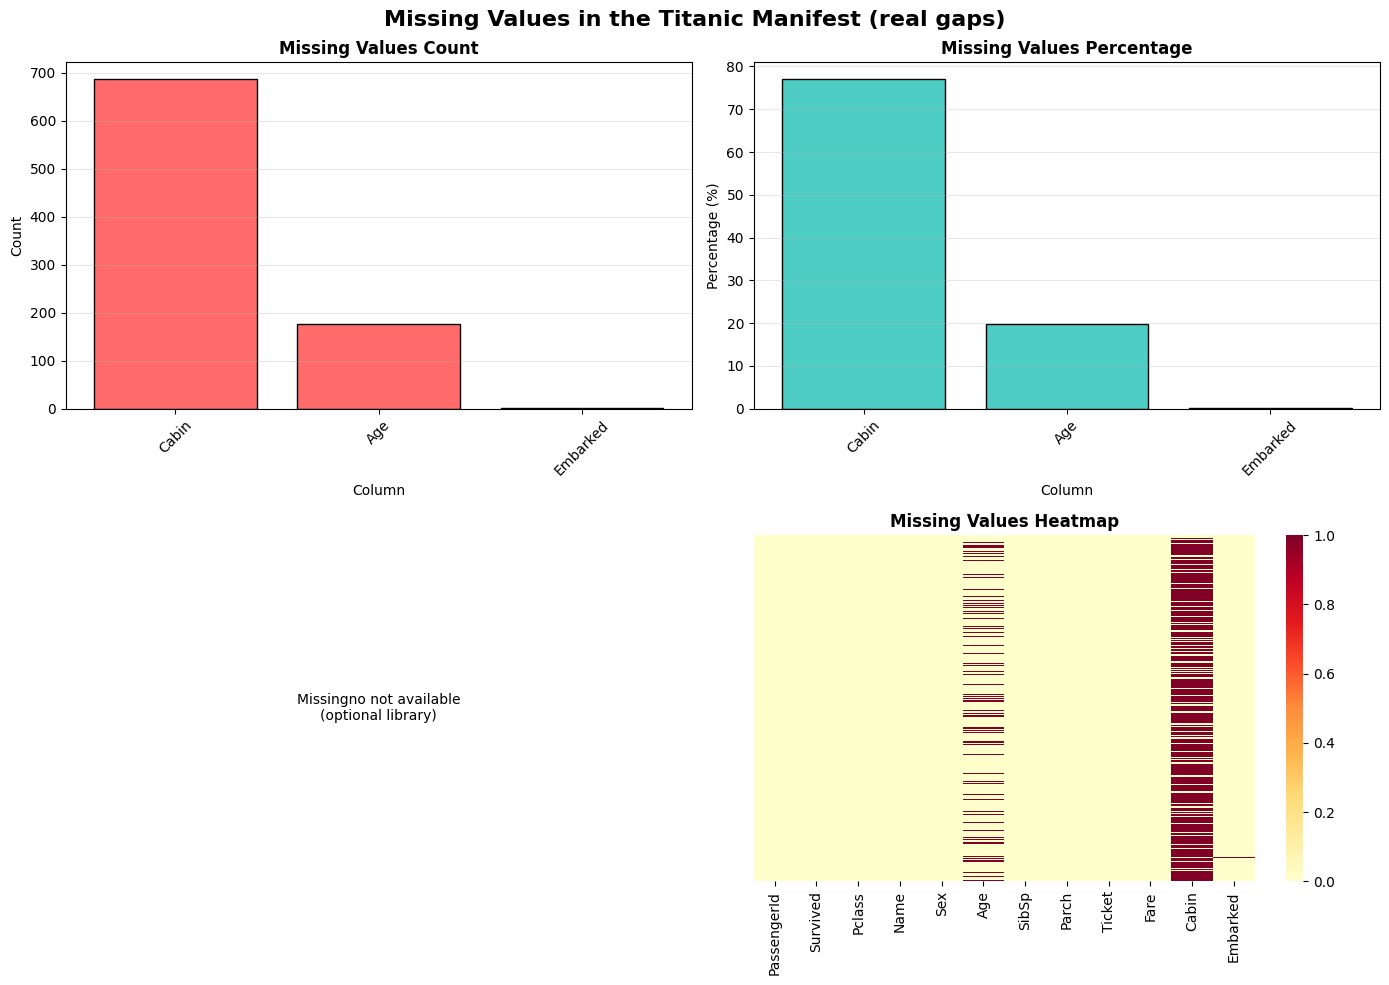

In [3]:
# WHAT: Count and chart missing values per column, then visualize WHERE in the table they occur.
# WHY: A count tells you how much is missing; the heatmap tells you whether the gaps have a pattern - and a pattern changes how you should fix them.
print("\n\n2. Detecting Missing Values")
print("-" * 70)
print("\nMissing values per column")
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
'Column': missing_counts.index, 'Missing Count': missing_counts.values,
'Missing %': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
# Visualize missing values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Missing Values in the Titanic Manifest (real gaps)', fontsize=16, weight='bold')
# Plot 1: Missing values bar chart
if len(missing_df) > 0:
    axes[0, 0].bar(missing_df['Column'], missing_df['Missing Count'],
                   color='#FF6B6B', edgecolor='black')
axes[0, 0].set_title('Missing Values Count', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Column')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Plot 2: Missing values percentage
if len(missing_df) > 0:
    axes[0, 1].bar(missing_df['Column'], missing_df['Missing %'],
                   color='#4ECDC4', edgecolor='black')
axes[0, 1].set_title('Missing Values Percentage', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Column')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Plot 3: Missing values matrix (if missingno available)
if MISSINGNO_AVAILABLE and msno is not None:
    try:
        msno.matrix(df, ax=axes[1, 0], sparkline=False)
        axes[1, 0].set_title('Missing Values Matrix', fontsize=12, weight='bold')
    except:
        axes[1, 0].text(0.5, 0.5, 'Missingno visualization\nnot available',
        ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].axis('off')
else:
    axes[1, 0].text(0.5, 0.5, 'Missingno not available\n(optional library)', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].axis('off')
# Plot 4: Heatmap of missing values
missing_heatmap = df.isnull()
sns.heatmap(missing_heatmap, yticklabels=False, cbar=True, ax=axes[1, 1],
cmap='YlOrRd')
axes[1, 1].set_title('Missing Values Heatmap', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Missing values visualization saved")

# Is the missingness random? Compare Cabin gaps across ticket classes.
cabin_by_class = df.groupby('Pclass')['Cabin'].apply(lambda s: s.isna().mean())
print("\nShare of passengers with NO cabin recorded, by ticket class:")
for pclass, share in cabin_by_class.items():
    print(f"   Class {pclass}: {share:.1%}")
print("   The gaps are NOT random. Cheaper tickets rarely came with a recorded cabin,")
print("   so 'Cabin is missing' is itself information about the passenger.")
print("   Statisticians call this MNAR - missing not at random (Rubin, 1976).")


## Part 3: Handling Missing Values

**BEFORE**: You found missing values but don't know how to fix them.

**AFTER**: You'll learn multiple strategies to handle missing values!

**Why this matters**: Different strategies work for different situations - choose wisely!

## Step 3: Multiple Strategies for Handling Missing Values

**BEFORE**: Missing values break our analysis.

**AFTER**: We'll use 5 different strategies on the real `Age` and `Embarked` columns —
and measure what each one does to the data.


In [4]:
# WHAT: Apply five missing-value strategies - drop, mean, median, mode, forward fill - each on a fresh copy, and measure the damage.
# WHY: There is no single right fix: dropping loses rows, mean/median suit numbers, mode suits categories, ffill suits ordered data.

print("\n\n3. Handling Missing Values")
print("-" * 70)

age_mean_before = df['Age'].mean()
age_std_before = df['Age'].std()
print(f"Reference, before any filling: Age mean {age_mean_before:.2f},"
      f" std {age_std_before:.2f}, from {df['Age'].notna().sum()} known values")

# Strategy 1: Drop rows with missing values
print("\nStrategy 1: Drop rows with ANY missing value")
df_dropped = df.dropna()
print(f"Original: {len(df)} rows → After dropping: {len(df_dropped)} rows"
      f" ({100 - len(df_dropped) / len(df) * 100:.0f}% of the data thrown away)")
print("   Cabin is missing for most passengers, so dropna() effectively deletes")
print("   everyone without a cabin - a biased survivor set, not a clean dataset.")

# Strategy 1b: drop the COLUMN instead of the rows
df_drop_col = df.drop(columns=['Cabin']).dropna()
print(f"Dropping the Cabin COLUMN first, then rows: {len(df_drop_col)} rows kept"
      f" - a far better trade")

# Strategy 2: Fill with mean (for numerical)
print("\nStrategy 2: Fill Age with the mean")
df_filled_mean = df.copy()
df_filled_mean['Age'] = df_filled_mean['Age'].fillna(df['Age'].mean())
print(f"Filled {df['Age'].isna().sum()} ages with {df['Age'].mean():.2f}")
print(f"   Age std BEFORE {age_std_before:.2f} → AFTER"
      f" {df_filled_mean['Age'].std():.2f}")
print("   The mean is unchanged by construction, but the spread SHRANK: we invented")
print("   177 perfectly average passengers. Imputation always understates variance.")

# Strategy 3: Fill with median
print("\nStrategy 3: Fill Age with the median")
df_filled_median = df.copy()
df_filled_median['Age'] = df_filled_median['Age'].fillna(df['Age'].median())
print(f"Filled with median {df['Age'].median():.2f}"
      f" → new mean {df_filled_median['Age'].mean():.2f}")
print("   Median resists outliers, so prefer it on skewed columns like Fare.")

# Strategy 3b: a smarter numeric fill - group median
df_filled_group = df.copy()
df_filled_group['Age'] = df_filled_group.groupby(['Pclass', 'Sex'])['Age'] \
                                        .transform(lambda s: s.fillna(s.median()))
print(f"\nStrategy 3b: median within each (Pclass, Sex) group"
      f" → std {df_filled_group['Age'].std():.2f}")
print("   Closer to the original spread, because 1st-class men and 3rd-class")
print("   children get different estimates instead of one global number.")

# Strategy 4: Fill with mode (for categorical)
print("\nStrategy 4: Fill Embarked with the mode (categorical)")
df_filled_mode = df.copy()
mode_port = df['Embarked'].mode()[0]
df_filled_mode['Embarked'] = df_filled_mode['Embarked'].fillna(mode_port)
print(f"Filled {df['Embarked'].isna().sum()} missing ports with '{mode_port}'"
      f" ({(df['Embarked'] == mode_port).mean():.0%} of passengers boarded there)")
print("   With only 2 missing values this is safe. With 200 it would not be.")

# Strategy 5: Forward fill (carry the previous value forward)
print("\nStrategy 5: Forward fill")
df_ffill = df.copy()
df_ffill['Embarked'] = df_ffill['Embarked'].ffill()
print(f"Missing Embarked after ffill: {df_ffill['Embarked'].isna().sum()}")
print("   ffill only makes sense when row ORDER means something (time series,")
print("   sensor logs). A passenger list is not ordered by anything meaningful,")
print("   so here it is a demonstration of the mechanic, not a recommendation.")




3. Handling Missing Values
----------------------------------------------------------------------
Reference, before any filling: Age mean 29.70, std 14.53, from 714 known values

Strategy 1: Drop rows with ANY missing value
Original: 891 rows → After dropping: 183 rows (79% of the data thrown away)
   Cabin is missing for most passengers, so dropna() effectively deletes
   everyone without a cabin - a biased survivor set, not a clean dataset.
Dropping the Cabin COLUMN first, then rows: 712 rows kept - a far better trade

Strategy 2: Fill Age with the mean
Filled 177 ages with 29.70
   Age std BEFORE 14.53 → AFTER 13.00
   The mean is unchanged by construction, but the spread SHRANK: we invented
   177 perfectly average passengers. Imputation always understates variance.

Strategy 3: Fill Age with the median
Filled with median 28.00 → new mean 29.36
   Median resists outliers, so prefer it on skewed columns like Fare.

Strategy 3b: median within each (Pclass, Sex) group → std 13.30
  

## 💬 Discuss

Two measured findings from the cells above: **`Cabin` is missing for 18.5% of first-class
passengers but 97.6% of third class** — the gap is not random, it is information. And
`dropna()` on all columns leaves **183 of 891 rows** — 79% of the data destroyed.

1. Because `Cabin` is missing mostly for cheap tickets, "no cabin recorded" predicts
   ticket class almost perfectly. Would you (a) drop the column, (b) fill it with
   `"unknown"`, or (c) replace it with a boolean `cabin_recorded` feature? Argue for one,
   then say what your choice does to a survival model — and whether that is a finding or a
   leak.
2. Ofqual's algorithm was, in effect, a group-median imputation: fill a student's missing
   grade from their school's history. The notebook's own "impute Age by group median" step
   is the same operation. What made one of them defensible and the other a national
   scandal? Name at least two differences that are not about the arithmetic.
3. Dropping rows keeps the data honest but shrinks it; imputing keeps the size but
   fabricates values. Your client has 891 rows and needs an answer this week. Which do you
   choose, and what one sentence do you put in the report so nobody is misled?


## Part 4: Detecting Duplicates

**BEFORE**: You have duplicate data but don't know where.

**AFTER**: You'll find all duplicates (complete rows or specific columns)!

**Why this matters**: Duplicates bias your analysis - detect them first!

## Step 4: Detecting Duplicates

**BEFORE**: Duplicates exist but are hidden.

**AFTER**: We'll find duplicates in entire rows or specific columns — and learn that a
repeated *key* is not always a mistake.


In [5]:
# WHAT: Count duplicates in both datasets - full-row copies and repeated key columns.
# WHY: A full-row copy is usually a data error; a repeated key can be perfectly legitimate, and telling them apart is the real skill.

print("\n\n4. Detecting Duplicates")
print("-" * 70)

# --- Titanic: are there duplicate PASSENGERS? ---
print("\nTitanic manifest:")
print(f"  Fully identical rows: {df.duplicated().sum()}")
print(f"  Duplicate PassengerId: {df.duplicated(subset=['PassengerId']).sum()}")
print(f"  Duplicate Name:        {df.duplicated(subset=['Name']).sum()}")

dup_tickets = df.duplicated(subset=['Ticket']).sum()
print(f"  Duplicate Ticket:      {dup_tickets}")
print("\n  ⚠ Read that last number carefully. A repeated ticket number is NOT an")
print("    error - families and servants travelled on one ticket. Example:")
shared = df['Ticket'].value_counts()
top_ticket = shared.index[0]
print(df[df['Ticket'] == top_ticket][['Name', 'Age', 'Ticket', 'Fare']].to_string(index=False))
print(f"    {shared.iloc[0]} real people, one ticket. Dropping them would delete")
print("    real passengers and change every survival statistic in this course.")

# --- 911 log: are there duplicate CALLS? ---
print("\nMontgomery County 911 log:")
dup_rows = calls.duplicated()
print(f"  Fully identical rows: {dup_rows.sum():,}"
      f" ({dup_rows.mean() * 100:.3f}% of the file)")
print(f"  Duplicate (timeStamp, addr, title) triples:"
      f" {calls.duplicated(subset=['timeStamp', 'addr', 'title']).sum():,}")

if dup_rows.sum() > 0:
    print("\n  An example of a genuinely duplicated call record:")
    example = calls[calls.duplicated(keep=False)].sort_values('timeStamp').head(2)
    print(example[['timeStamp', 'title', 'twp', 'addr']].to_string(index=False))
    print("\n  Same second, same address, same emergency type: the dispatch system")
    print("  wrote the record twice. THESE should go.")




4. Detecting Duplicates
----------------------------------------------------------------------

Titanic manifest:
  Fully identical rows: 0
  Duplicate PassengerId: 0
  Duplicate Name:        0
  Duplicate Ticket:      210

  ⚠ Read that last number carefully. A repeated ticket number is NOT an
    error - families and servants travelled on one ticket. Example:
                                                     Name  Age Ticket   Fare
                              Andersson, Mr. Anders Johan 39.0 347082 31.275
                        Andersson, Miss. Ellis Anna Maria  2.0 347082 31.275
                     Andersson, Miss. Ingeborg Constanzia  9.0 347082 31.275
                        Andersson, Miss. Sigrid Elisabeth 11.0 347082 31.275
Andersson, Mrs. Anders Johan (Alfrida Konstantia Brogren) 39.0 347082 31.275
                       Andersson, Miss. Ebba Iris Alfrida  6.0 347082 31.275
                  Andersson, Master. Sigvard Harald Elias  4.0 347082 31.275
    7 real people,

  Fully identical rows: 240 (0.036% of the file)
  Duplicate (timeStamp, addr, title) triples: 2,247

  An example of a genuinely duplicated call record:


          timeStamp                      title         twp                      addr
2015-12-12 19:41:03 EMS: ALTERED MENTAL STATUS MARLBOROUGH UPPER RIDGE RD & PRICE RD
2015-12-12 19:41:03 EMS: ALTERED MENTAL STATUS MARLBOROUGH UPPER RIDGE RD & PRICE RD

  Same second, same address, same emergency type: the dispatch system
  wrote the record twice. THESE should go.


## Part 5: Removing Duplicates

**BEFORE**: You found duplicates but haven't removed them yet.

**AFTER**: You'll remove duplicates with different options (keep first/last)!

**Why this matters**: Removing duplicates ensures each record is counted once!

## Step 5: Removing Duplicates

**BEFORE**: Duplicates are detected but still in the data.

**AFTER**: We'll remove the ones that are genuine errors — and deliberately keep the
ones that are not.


In [6]:
# WHAT: Remove duplicates with drop_duplicates, comparing keep='first' vs keep='last', and show when NOT to remove.
# WHY: WHICH copy you keep matters - and deciding whether to remove at all matters even more.

print("\n\n5. Removing Duplicates")
print("-" * 70)

# --- The 911 log: these duplicates are real errors, so remove them ---
calls_no_dupes = calls.drop_duplicates()
removed = len(calls) - len(calls_no_dupes)
print(f"911 log: {len(calls):,} rows → {len(calls_no_dupes):,} rows"
      f" ({removed:,} identical copies removed)")

# keep='first' vs keep='last' on a looser key: same call, possibly updated details
key = ['timeStamp', 'addr', 'title']
first_kept = calls.drop_duplicates(subset=key, keep='first')
last_kept = calls.drop_duplicates(subset=key, keep='last')
print(f"Collapsing on {key}:")
print(f"  keep='first': {len(first_kept):,} rows")
print(f"  keep='last':  {len(last_kept):,} rows  (same count, different rows kept)")
differs = (first_kept.reset_index(drop=True) != last_kept.reset_index(drop=True)).any(axis=1).sum()
print(f"  Rows where the two choices actually differ: {differs:,}")
print("  Use keep='last' when later records are corrections/updates of earlier ones.")

# --- The Titanic tickets: these are NOT errors, so keep them ---
naive = df.drop_duplicates(subset=['Ticket'])
print(f"\nTitanic: naively de-duplicating on Ticket would leave {len(naive)} of"
      f" {len(df)} passengers")
lost = df[df.duplicated(subset=['Ticket'], keep='first')]
print(f"  It would delete {len(lost)} real people, including"
      f" {int(lost['Survived'].sum())} survivors.")
print(f"  Survival rate before: {df['Survived'].mean():.3f}"
      f" → after this 'cleaning': {naive['Survived'].mean():.3f}")
print("  A cleaning step that changes your headline number is a red flag, not a win.")
print("\n💡 Rule of thumb: drop_duplicates() on ALL columns is usually safe.")
print("   drop_duplicates(subset=...) needs a reason you can state out loud.")




5. Removing Duplicates
----------------------------------------------------------------------


911 log: 663,522 rows → 663,282 rows (240 identical copies removed)


Collapsing on ['timeStamp', 'addr', 'title']:
  keep='first': 661,275 rows
  keep='last':  661,275 rows  (same count, different rows kept)
  Rows where the two choices actually differ: 86,607
  Use keep='last' when later records are corrections/updates of earlier ones.

Titanic: naively de-duplicating on Ticket would leave 681 of 891 passengers
  It would delete 210 real people, including 103 survivors.
  Survival rate before: 0.384 → after this 'cleaning': 0.351
  A cleaning step that changes your headline number is a red flag, not a win.

💡 Rule of thumb: drop_duplicates() on ALL columns is usually safe.
   drop_duplicates(subset=...) needs a reason you can state out loud.


## 💬 Discuss

Read the numbers you just produced very carefully. De-duplicating the manifest on `Ticket`
would leave **681 of 891 passengers** — deleting **210 real people, 103 of them
survivors** — and would move the reported survival rate from **0.384 to 0.351**.

1. That is a cleaning step that changes the headline number. Give a rule your team could
   actually follow that would have caught it *before* the number moved. Is "always inspect
   what you delete" enough, at 663,522 rows?
2. In the 911 log, `keep='first'` and `keep='last'` both leave 661,275 rows, but the rows
   differ in **86,607** cases. When would you prefer the last record over the first, and
   what would you need to know about the dispatch system to be sure?
3. A repeated ticket number is a family travelling together, not an error. Name another
   column in a dataset you have seen where repetition is *expected*, and one where it is
   *always* a defect. What distinguishes the two?


## 🎯 Summary: What We Learned

## Final Summary

In [7]:
# WHAT: Print a recap of missing-value and duplicate handling.
# WHY: These steps run in almost every real project - the summary doubles as a reusable cleaning checklist.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You could load data but didn't know how to handle missing values")
print("   - You didn't know how to detect or remove duplicates")
print("   - Your data had quality issues that broke your analysis")

print("\n✅ AFTER this notebook:")
print("   - You can detect missing values and understand their patterns")
print("   - You know 5 strategies to handle missing values (drop, mean, median, mode, ffill)")
print("   - You can measure what an imputation did to the spread of a column")
print("   - You can detect duplicates (complete rows or specific columns)")
print("   - You can remove duplicates with different options (keep first/last)")
print("   - You can visualize missing data patterns with missingno and seaborn")

print("\n📚 Key Concepts Covered:")
print("   1. Missing Value Detection (isnull(), counting, percentages)")
print("   2. Missing Value Handling (drop, mean, median, mode, forward fill)")
print("   3. Duplicate Detection (duplicated(), subset columns)")
print("   4. Duplicate Removal (drop_duplicates(), keep options, and when NOT to)")
print("   5. Visualization (missingno matrix, heatmaps, bar charts)")

print("\n🔗 Where These Skills Fit:")
print("   - Essential cleaning step AFTER loading data")
print("   - Required BEFORE outlier detection and transformations")
print("   - Critical for machine learning (models need clean data)")
print("   - Foundation for reliable data analysis!")

print("\n➡️  Next Steps:")
print("   - Continue to Example 3: Outliers & Transformation")
print("   - You'll learn how to handle outliers and transform data")
print("   - Clean data (no missing values, no duplicates) is essential first!")

print("\n" + "=" * 70)
plt.show()



🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You could load data but didn't know how to handle missing values
   - You didn't know how to detect or remove duplicates
   - Your data had quality issues that broke your analysis

✅ AFTER this notebook:
   - You can detect missing values and understand their patterns
   - You know 5 strategies to handle missing values (drop, mean, median, mode, ffill)
   - You can measure what an imputation did to the spread of a column
   - You can detect duplicates (complete rows or specific columns)
   - You can remove duplicates with different options (keep first/last)
   - You can visualize missing data patterns with missingno and seaborn

📚 Key Concepts Covered:
   1. Missing Value Detection (isnull(), counting, percentages)
   2. Missing Value Handling (drop, mean, median, mode, forward fill)
   3. Duplicate Detection (duplicated(), subset columns)
   4. Duplicate Removal (drop_duplicates(), keep options, and when NOT to)
   5. Visualiza

## 🚫 When Missing Values & Duplicates Cleaning Hits a Dead End

**BEFORE**: We've cleaned missing values and duplicates successfully.

**AFTER**: We discover the cleaned data still has problems - outliers skewing our analysis!

**Why this matters**: Missing values and duplicates are fixed, but outliers can still distort our results!

---

### The Problem We've Discovered

We've learned:
- ✅ How to detect and handle missing values
- ✅ How to detect and remove duplicates
- ✅ How to clean data for analysis

**But we have a problem:**
- ❓ **What if the data has extreme values (outliers)?**
- ❓ **What if outliers are skewing our statistics?**
- ❓ **What if we need to transform the data distribution?**

**The Dead End:**
- We've fixed missing values and duplicates
- But the data may still have outliers affecting analysis
- Outliers can skew statistics, break assumptions, and lead to wrong conclusions

---

### Demonstrating the Problem

Let's check the cleaned data - does it have outliers?

In [8]:
# WHAT: Check the cleaned data for outliers with the IQR rule.
# WHY: Cleaning is layered - after gaps and duplicates, extreme values are the next quality problem, and the next notebook's topic.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Outliers in Cleaned Data")
print("=" * 70)

# Use the cleaned data: Age imputed within (Pclass, Sex) groups, Cabin column dropped.
df_clean = df_filled_group.drop(columns=['Cabin'])
df_clean = df_clean.dropna(subset=['Embarked'])

print(f"\n📊 Checking cleaned dataset for outliers...")
print(f"   Dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   ✓ Missing ages imputed by group median")
print(f"   ✓ Cabin column dropped (77% missing)")
print(f"   ✓ Remaining missing values: {df_clean.isnull().sum().sum()}")

# Check for outliers using the IQR method on the Fare column
print(f"\n⚠️  Checking for Outliers (using IQR method):")

Q1_fare = df_clean['Fare'].quantile(0.25)
Q3_fare = df_clean['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

outliers_fare = df_clean[(df_clean['Fare'] < lower_bound_fare) |
                         (df_clean['Fare'] > upper_bound_fare)]
print(f"\n   Fare Outliers:")
print(f"   - Lower bound: {lower_bound_fare:,.2f}")
print(f"   - Upper bound: {upper_bound_fare:,.2f}")
print(f"   - Outliers found: {len(outliers_fare)}"
      f" ({len(outliers_fare) / len(df_clean) * 100:.1f}%)")
print(f"   - Highest fare in the data: {df_clean['Fare'].max():,.2f}")
print(f"   - Median fare:              {df_clean['Fare'].median():,.2f}")
print(f"   - The most expensive ticket cost"
      f" {df_clean['Fare'].max() / df_clean['Fare'].median():.0f}x the median one.")
print(f"   - Mean fare {df_clean['Fare'].mean():.2f} vs median"
      f" {df_clean['Fare'].median():.2f}: the mean is dragged upward by the extremes.")
print("\n   And these are NOT errors - some passengers really did pay that much.")
print("   Deciding what to do about a legitimate extreme value is the next problem.")

print("\n" + "=" * 70)



🚫 DEMONSTRATING THE DEAD END: Outliers in Cleaned Data

📊 Checking cleaned dataset for outliers...
   Dataset shape: 889 rows × 11 columns
   ✓ Missing ages imputed by group median
   ✓ Cabin column dropped (77% missing)
   ✓ Remaining missing values: 0

⚠️  Checking for Outliers (using IQR method):

   Fare Outliers:
   - Lower bound: -26.76
   - Upper bound: 65.66
   - Outliers found: 114 (12.8%)
   - Highest fare in the data: 512.33
   - Median fare:              14.45
   - The most expensive ticket cost 35x the median one.
   - Mean fare 32.10 vs median 14.45: the mean is dragged upward by the extremes.

   And these are NOT errors - some passengers really did pay that much.
   Deciding what to do about a legitimate extreme value is the next problem.



### What We Need Next

**The Solution**: We need outlier detection and data transformation techniques:
- **Outlier detection**: Identify extreme values using statistical methods
- **Outlier handling**: Remove, transform, or cap outliers
- **Data transformation**: Normalize, scale, or transform distributions

**This dead end leads us to Example 3: Outliers & Transformation**
- Example 3 will teach us how to detect and handle outliers
- We'll learn data transformation techniques
- This completes the data cleaning process so we have truly clean data for analysis!


## ⚠️ Where this breaks

- **Imputation always shrinks variance, and standard errors go with it.** Measured above:
  filling `Age` with the mean pulled the standard deviation from 14.53 to 13.00. Any
  p-value, confidence interval or model uncertainty computed afterwards is optimistic and
  does not know it. If the uncertainty matters, use *multiple imputation* (Rubin, 1987) and
  report the spread across imputations — a single filled column cannot express "we don't
  know".
- **The three missingness mechanisms need different treatments, and only one is easy.**
  Missing completely at random (MCAR) tolerates almost anything. Missing at random (MAR)
  needs the fill to condition on the observed columns. **Missing not at random (MNAR)** —
  which is what `Cabin` is here, since cheap tickets simply were not assigned recorded
  cabins — cannot be fixed by any fill computed from the data, because the reason for the
  gap is outside it. No amount of cleverness recovers information that was never recorded.
- **`dropna()` is a sampling decision disguised as a cleaning step.** Dropping every row
  with any gap left 183 of 891 rows here, and that survivor set is *biased* — it is
  essentially the passengers rich enough to have a cabin on record. A smaller, cleaner,
  wrong dataset.
- **`drop_duplicates(subset=...)` needs a reason you can say out loud.** On all columns it
  is usually safe. On a chosen key it is a claim that the key is unique, and the Titanic
  ticket numbers show what happens when that claim is false.
- **The assumption that must hold: your fill is a plausible value for *that* row.** Group
  medians are defensible when the group is genuinely homogeneous and reasonably large.
  Ofqual's failure was applying a group-derived value to individuals whose group was tiny
  or unrepresentative.
- **The cheaper, more honest alternative:** leave the gap. Modern gradient-boosting
  implementations (XGBoost, LightGBM) and several sklearn estimators handle `NaN` natively
  and learn a split direction for missing. Adding a `was_missing` indicator column next to
  a filled value costs nothing and preserves what imputation destroys.


## 📚 References

1. Rubin, D. B. (1976). *Inference and Missing Data*. Biometrika, 63(3), 581-592. <https://doi.org/10.1093/biomet/63.3.581>
2. Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data*, 3rd ed. Wiley.
3. van Buuren, S. (2018). *Flexible Imputation of Missing Data*, 2nd ed. Chapman & Hall/CRC.